# Cooling Mode ML Correction — Overshoot/Undershoot Regression

**Purpose:** Build a LightGBM regression model for cooling mode that predicts
the required outlet-temperature correction (ΔT_outlet in °C), analogous to
the heating correction model from notebook 08.

**Key differences from heating:**
- Cooling target ≈ 23.0°C (vs 22.6°C heating)
- S_H_cooling uses OE_cooling ≈ 0.20 (vs 0.85 heating) → lower sensitivity
- AT forecasts extend to 12h (vs 4h heating)
- PV forecasts extend to 12h (vs 4h heating)
- Solar/PV features are more important (cooling happens during sunny periods)
- The existing cooling CSV has a binary classifier label → we compute a regression label

**Architecture (same as 08_):**
```
Training:   adjusted_label = -(T_future - T_current) / S_H_cooling
Inference:  full_correction = model.predict(X) - indoor_margin / S_H_cooling
```

## 0. Configuration

In [1]:
import os
import math

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../.."))
LOGS_DIR = os.path.join(PROJECT_ROOT, "Logs_and_models")

TRAINING_CSV = os.path.join(LOGS_DIR, "cooling_training_data.csv.gz")

# ── Label & physics ─────────────────────────────────────────────────────────
LABEL_HORIZON_H = 4              # hours ahead (match heating for consistency)
STEPS_PER_HOUR = 6               # ~10-min resolution
COOLING_TARGET_C = 23.0          # cooling target temperature

# ── Cooling-mode thermal parameters (from NB16 calibration) ─────────────────
OE_COOLING = 0.20                # OE_cooling ≈ 0.20 (much lower than heating 0.85)
HLC = 0.1206                     # kW/K (same building, mode-invariant)
TAU_ROOM = 4.84                  # hours (same slab, mode-invariant)

# S_H = [OE / (OE + HLC)] × [1 − exp(−H/τ)]
def compute_s_h(oe, hlc, tau, h):
    denom = oe + hlc
    if denom < 1e-6 or tau < 1e-3:
        return 0.0
    return (oe / denom) * (1.0 - math.exp(-h / tau))

S_H = compute_s_h(OE_COOLING, HLC, TAU_ROOM, LABEL_HORIZON_H)

# ── Train / test split ─────────────────────────────────────────────────────
TRAIN_FRACTION = 0.75

# ── LightGBM defaults ──────────────────────────────────────────────────────
LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 300,
    "learning_rate": 0.07,
    "max_depth": 4,
    "num_leaves": 30,
    "min_child_samples": 33,
    "reg_alpha": 0.66,
    "reg_lambda": 3.63,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

print("Config loaded.")
print(f"  Training CSV : {TRAINING_CSV}")
print(f"  Label horizon: {LABEL_HORIZON_H}h ({LABEL_HORIZON_H * STEPS_PER_HOUR} steps)")
print(f"  Target temp  : {COOLING_TARGET_C}°C")
print(f"  OE_cooling   : {OE_COOLING}")
print(f"  HLC          : {HLC}")
print(f"  τ_room       : {TAU_ROOM}h")
print(f"  S_H_cooling  : {S_H:.4f}")
print(f"  (Heating S_H ≈ 0.492 for comparison)")

Config loaded.
  Training CSV : c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\cooling_training_data.csv.gz
  Label horizon: 4h (24 steps)
  Target temp  : 23.0°C
  OE_cooling   : 0.2
  HLC          : 0.1206
  τ_room       : 4.84h
  S_H_cooling  : 0.3508
  (Heating S_H ≈ 0.492 for comparison)


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

import lightgbm as lgb

try:
    import optuna
    USE_OPTUNA = True
except ImportError:
    USE_OPTUNA = False

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 5)
print(f"LightGBM ✓  Optuna={'✓' if USE_OPTUNA else '✗'}")

LightGBM ✓  Optuna=✓


## 2. Data Loading & Regression Label Construction

The cooling CSV has a **binary** label (overheating classifier).
We need to compute a **regression** label for outlet correction:

```
label_reg[t] = -(indoor_temp[t + N_STEPS] - COOLING_TARGET) / S_H_cooling
```

Positive = outlet should have been lowered more (undercooling),
Negative = outlet was too low (overcooling).

In [3]:
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"\nExisting binary label: 0={( df['label']==0).sum():,}  1={(df['label']==1).sum():,}")

# ── Compute regression label ───────────────────────────────────────────────
N_STEPS = LABEL_HORIZON_H * STEPS_PER_HOUR  # 24 steps = 4h

future_indoor = df["indoor_temp"].shift(-N_STEPS)
df["label_reg"] = -(future_indoor - COOLING_TARGET_C) / S_H

# Clip to ±10°C (S_H is small → larger label magnitudes than heating)
df["label_reg"] = df["label_reg"].clip(-10.0, 10.0)

# Drop rows where future indoor is NaN (last N_STEPS rows)
n_before = len(df)
df = df.dropna(subset=["label_reg"]).copy()
print(f"After dropping trailing NaN labels: {n_before:,} → {len(df):,} rows")

print(f"\nRegression label stats:")
print(f"  mean = {df['label_reg'].mean():.3f}")
print(f"  std  = {df['label_reg'].std():.3f}")
print(f"  min  = {df['label_reg'].min():.3f}")
print(f"  max  = {df['label_reg'].max():.3f}")
print(f"  Positive (undershoot): {(df['label_reg'] > 0).sum():,} ({(df['label_reg'] > 0).mean()*100:.1f}%)")
print(f"  Negative (overshoot) : {(df['label_reg'] < 0).sum():,} ({(df['label_reg'] < 0).mean()*100:.1f}%)")

Loaded 47,941 rows × 76 columns

Existing binary label: 0=16,479  1=31,462
After dropping trailing NaN labels: 47,941 → 47,917 rows

Regression label stats:
  mean = -0.041
  std  = 1.247
  min  = -3.791
  max  = 7.069
  Positive (undershoot): 23,024 (48.0%)
  Negative (overshoot) : 24,526 (51.2%)


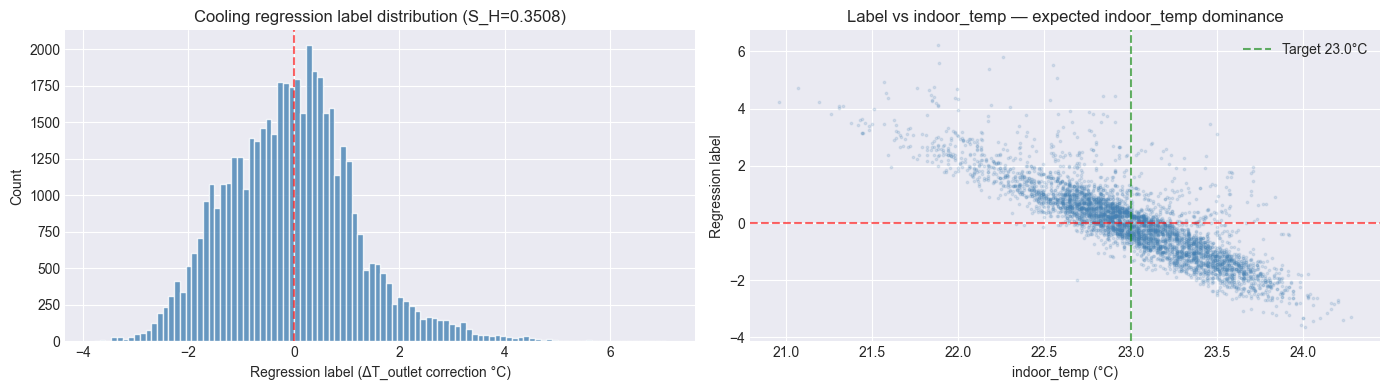

In [4]:
# ── Label distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["label_reg"], bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.6)
axes[0].set_xlabel("Regression label (ΔT_outlet correction °C)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Cooling regression label distribution (S_H={S_H:.4f})")

sample_idx = np.random.RandomState(42).choice(len(df), min(5000, len(df)), replace=False)
axes[1].scatter(df["indoor_temp"].iloc[sample_idx], df["label_reg"].iloc[sample_idx],
                alpha=0.15, s=3, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.6)
axes[1].axvline(COOLING_TARGET_C, color="green", linestyle="--", alpha=0.6,
                label=f"Target {COOLING_TARGET_C}°C")
axes[1].set_xlabel("indoor_temp (°C)")
axes[1].set_ylabel("Regression label")
axes[1].set_title("Label vs indoor_temp — expected indoor_temp dominance")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Residualized Label

Same approach as heating 08_:
```
adjusted_label = label_reg + indoor_margin / S_H = -(T_future - T_current) / S_H
```
Model predicts temperature CHANGE, not distance-to-target.

In [5]:
# ── Engineer new features (same as heating 08_ + cooling-specific) ─────────
# thermal_power_w: convert thermal_power_kw to W
df["thermal_power_w"] = df["thermal_power_kw"] * 1000.0

# Q_wp placeholder (cooling CSV doesn't have flow_rate, use thermal_power_w)
if "Q_wp" not in df.columns:
    df["Q_wp"] = df["thermal_power_w"]

# New engineered features
df["cumulative_Q_wp_4h"] = df["Q_wp"].rolling(N_STEPS, min_periods=1).sum()
df["indoor_accel"] = df["indoor_trend_1h"].diff(1).fillna(0)
df["AT_forecast_trend"] = df["AT_roh_4h"] - df["AT"]
df["pv_cumulative_4h"] = df["PV_Generate"].rolling(N_STEPS, min_periods=1).sum()
df["thermal_momentum"] = df["thermal_power_rolling_1h"] * 1000.0 * df["delta_t"]

print("New features engineered:")
for f in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
          "pv_cumulative_4h", "thermal_momentum"]:
    print(f"  {f:25s}  mean={df[f].mean():>12.2f}  std={df[f].std():>12.2f}")

New features engineered:
  cumulative_Q_wp_4h         mean=      945.76  std=    27823.23
  indoor_accel               mean=        0.00  std=        0.04
  AT_forecast_trend          mean=        0.00  std=        7.83
  pv_cumulative_4h           mean=    53685.09  std=    60713.95
  thermal_momentum           mean=     1773.25  std=     3962.69


S_H_cooling = 0.3508

Original reg label: mean=-0.041  std=1.247
Adjusted label:     mean=-0.084  std=2.407

Corr(indoor_temp, original_label)  = -0.8614
Corr(indoor_temp, adjusted_label)  = -0.9648


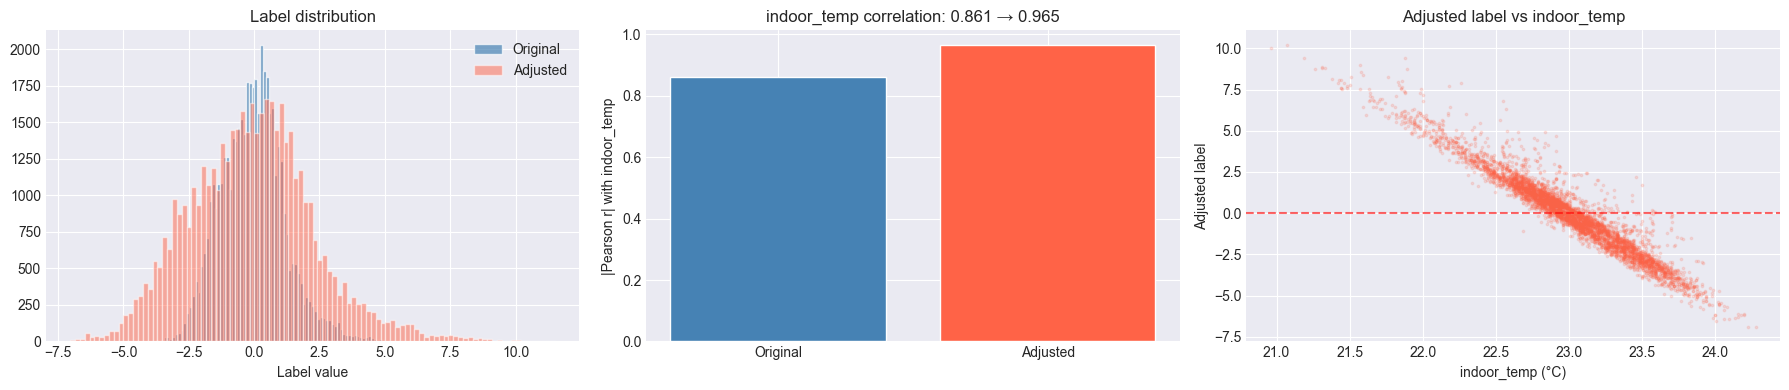

In [6]:
# ── Compute adjusted (residualized) label ──────────────────────────────────
df["adjusted_label"] = df["label_reg"] + df["indoor_margin"] / S_H

print(f"S_H_cooling = {S_H:.4f}")
print(f"\nOriginal reg label: mean={df['label_reg'].mean():.3f}  std={df['label_reg'].std():.3f}")
print(f"Adjusted label:     mean={df['adjusted_label'].mean():.3f}  std={df['adjusted_label'].std():.3f}")

r_orig = df[["indoor_temp", "label_reg"]].corr().iloc[0, 1]
r_adj = df[["indoor_temp", "adjusted_label"]].corr().iloc[0, 1]
print(f"\nCorr(indoor_temp, original_label)  = {r_orig:+.4f}")
print(f"Corr(indoor_temp, adjusted_label)  = {r_adj:+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df["label_reg"], bins=100, color="steelblue", edgecolor="white", alpha=0.7, label="Original")
axes[0].hist(df["adjusted_label"], bins=100, color="tomato", edgecolor="white", alpha=0.5, label="Adjusted")
axes[0].set_xlabel("Label value"); axes[0].set_title("Label distribution"); axes[0].legend()

axes[1].bar(["Original", "Adjusted"], [abs(r_orig), abs(r_adj)],
            color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_ylabel("|Pearson r| with indoor_temp")
axes[1].set_title(f"indoor_temp correlation: {abs(r_orig):.3f} → {abs(r_adj):.3f}")

sample = np.random.RandomState(42).choice(len(df), min(5000, len(df)), replace=False)
axes[2].scatter(df["indoor_temp"].iloc[sample], df["adjusted_label"].iloc[sample],
                alpha=0.15, s=3, color="tomato")
axes[2].axhline(0, color="red", linestyle="--", alpha=0.6)
axes[2].set_xlabel("indoor_temp (°C)"); axes[2].set_ylabel("Adjusted label")
axes[2].set_title("Adjusted label vs indoor_temp")
plt.tight_layout(); plt.show()

## 3b. Outlier Filtering (Forward-Looking Label Contamination)

Same approach as heating 08_: if a disruptive event occurs in [t, t+4h],
the label at time t is contaminated.

In [7]:
n_before = len(df)

# 1. Fireplace: uncontrolled heat — forward-looking window
fp_fwd = df["fireplace_on"].iloc[::-1].rolling(N_STEPS, min_periods=1).max().iloc[::-1]
fp_mask = fp_fwd.fillna(0) > 0

# 2. Window-open: rapid indoor_temp drop > 0.3°C in 30min (3 steps)
indoor_drop = df["indoor_temp"].diff(3)
window_event = (indoor_drop < -0.3).astype(float)
window_fwd = window_event.iloc[::-1].rolling(N_STEPS, min_periods=1).max().iloc[::-1]
window_mask = window_fwd.fillna(0) > 0

# 3. PV data spike: extreme sensor error
pv_p999 = df["PV_Generate"].quantile(0.999)
pv_threshold = pv_p999 * 1.5
pv_mask = df["PV_Generate"] > pv_threshold

# 4. Extreme label values (likely sensor glitch / DHW)
label_extreme = df["adjusted_label"].abs() > 8.0

outlier_mask = fp_mask | window_mask | pv_mask | label_extreme

print("=== OUTLIER DETECTION ===")
print(f"  Fireplace contaminated:   {fp_mask.sum():>6,} rows ({fp_mask.mean()*100:.1f}%)")
print(f"  Window-open contaminated: {window_mask.sum():>6,} rows ({window_mask.mean()*100:.1f}%)")
print(f"  PV spike:                 {pv_mask.sum():>6,} rows ({pv_mask.mean()*100:.1f}%)")
print(f"  Extreme label:            {label_extreme.sum():>6,} rows ({label_extreme.mean()*100:.1f}%)")
print(f"  Total flagged:            {outlier_mask.sum():>6,} rows ({outlier_mask.mean()*100:.1f}%)")

df = df[~outlier_mask].copy()
print(f"\n✓ {n_before:,} → {len(df):,} rows ({n_before - len(df):,} removed, "
      f"{(n_before - len(df)) / n_before * 100:.1f}%)")
print(f"\nCleaned label: mean={df['adjusted_label'].mean():.3f}  std={df['adjusted_label'].std():.3f}")

=== OUTLIER DETECTION ===
  Fireplace contaminated:        0 rows (0.0%)
  Window-open contaminated:  3,141 rows (6.6%)
  PV spike:                      0 rows (0.0%)
  Extreme label:               188 rows (0.4%)
  Total flagged:             3,274 rows (6.8%)

✓ 47,917 → 44,643 rows (3,274 removed, 6.8%)

Cleaned label: mean=-0.215  std=2.318


## 4. Feature Selection

Adapted from heating 08_ with cooling-specific modifications:
- `indoor_temp` REMOVED (use `indoor_margin` — physics input)
- `living_room_temp` REMOVED (r≈1.0 with indoor_temp)
- AT forecasts up to 4h (CSV has up to 12h but 4h matches label horizon)
- PV forecasts up to 4h
- Cooling-specific features included

In [8]:
FEATURE_COLS = [
    # ── Indoor state (NO raw indoor_temp) ──────────────────────────────────
    "indoor_margin",
    "indoor_trend_30m",
    "indoor_trend_1h",
    "indoor_temp_gradient",
    "indoor_margin_rate",
    "is_overshoot",
    "indoor_accel",               # NEW
    "indoor_momentum",            # cooling-specific

    # ── Outdoor temperature & forecasts ────────────────────────────────────
    "AT",
    "at_delta_indoor",
    "AT_roh_1h",
    "AT_roh_2h",
    "AT_roh_3h",
    "AT_roh_4h",
    "AT_forecast_trend",          # NEW
    "cum_at_excess_4h",           # cooling-specific
    "max_at_forecast",            # cooling-specific

    # ── PV / Solar ─────────────────────────────────────────────────────────
    "PV_Generate",
    "pv_roll_1h",
    "pv_roll_2h",
    "pv_forecast_1h",
    "pv_forecast_2h",
    "pv_forecast_3h",
    "pv_forecast_4h",
    "pv_forecast_delta",
    "solar_thermal_proxy",
    "shading_proxy",
    "pv_cumulative_4h",           # NEW
    "cum_pv_forecast_4h",         # cooling-specific

    # ── HP thermal state ───────────────────────────────────────────────────
    "VLT",
    "RLT",
    "delta_t",
    "outlet_indoor_diff",
    "thermal_power_w",
    "thermal_power_rolling_1h",
    "Q_wp",
    "cumulative_Q_wp_4h",         # NEW
    "thermal_momentum",           # NEW
    "slab_stored_heat",           # cooling-specific

    # ── External heat sources ──────────────────────────────────────────────
    "fireplace_on",
    "fireplace_lag_30m",
    "fireplace_lag_1h",
    "fireplace_lag_2h",
    "tv_on",
    "tv_lag_30m",
    "tv_lag_1h",

    # ── Slab thermal state ─────────────────────────────────────────────────
    "d_inlet_temp_60min",
    "is_equilibrium",

    # ── Context / physics ──────────────────────────────────────────────────
    "wind_speed",
    "is_hp_active",
    "is_weekend",
    "heat_loss_driving_force",
    "delta_T_indoor_lag1",
    "heat_loss_interaction",

    # ── Trajectory-derived physics ─────────────────────────────────────────
    "traj_predicted_error",
    "traj_convergence_rate",
    "traj_reaches_target_hours",
    "traj_overshoot_magnitude",
    "traj_equilibrium_gap",

    # ── Cyclical time ──────────────────────────────────────────────────────
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

# Validate
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"⚠️  {len(missing)} features not found (skipped): {missing}")
FEATURE_COLS = available

print(f"\n✓ Using {len(FEATURE_COLS)} features")
for i, f in enumerate(FEATURE_COLS):
    new = " ← NEW" if f in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
                             "pv_cumulative_4h", "thermal_momentum"] else ""
    cool = " ← COOLING" if f in ["indoor_momentum", "cum_at_excess_4h", "max_at_forecast",
                                  "cum_pv_forecast_4h", "slab_stored_heat"] else ""
    print(f"  {i+1:2d}. {f}{new}{cool}")


✓ Using 63 features
   1. indoor_margin
   2. indoor_trend_30m
   3. indoor_trend_1h
   4. indoor_temp_gradient
   5. indoor_margin_rate
   6. is_overshoot
   7. indoor_accel ← NEW
   8. indoor_momentum ← COOLING
   9. AT
  10. at_delta_indoor
  11. AT_roh_1h
  12. AT_roh_2h
  13. AT_roh_3h
  14. AT_roh_4h
  15. AT_forecast_trend ← NEW
  16. cum_at_excess_4h ← COOLING
  17. max_at_forecast ← COOLING
  18. PV_Generate
  19. pv_roll_1h
  20. pv_roll_2h
  21. pv_forecast_1h
  22. pv_forecast_2h
  23. pv_forecast_3h
  24. pv_forecast_4h
  25. pv_forecast_delta
  26. solar_thermal_proxy
  27. shading_proxy
  28. pv_cumulative_4h ← NEW
  29. cum_pv_forecast_4h ← COOLING
  30. VLT
  31. RLT
  32. delta_t
  33. outlet_indoor_diff
  34. thermal_power_w
  35. thermal_power_rolling_1h
  36. Q_wp
  37. cumulative_Q_wp_4h ← NEW
  38. thermal_momentum ← NEW
  39. slab_stored_heat ← COOLING
  40. fireplace_on
  41. fireplace_lag_30m
  42. fireplace_lag_1h
  43. fireplace_lag_2h
  44. tv_on
  45. tv_

## 5. Train / Validation Split

In [9]:
extra_cols = [c for c in ["label_reg", "adjusted_label", "indoor_margin"] if c not in FEATURE_COLS]
model_df = df[FEATURE_COLS + extra_cols].dropna()
print(f"Rows with complete data: {len(model_df):,} (dropped {len(df) - len(model_df):,} NaN)")

X = model_df[FEATURE_COLS].values
y_adj = model_df["adjusted_label"].values
y_orig = model_df["label_reg"].values
margin = model_df["indoor_margin"].values

split_idx = int(len(model_df) * TRAIN_FRACTION)
X_train, X_val = X[:split_idx], X[split_idx:]
y_adj_train, y_adj_val = y_adj[:split_idx], y_adj[split_idx:]
y_orig_train, y_orig_val = y_orig[:split_idx], y_orig[split_idx:]
margin_val = margin[split_idx:]

print(f"\nTraining: {len(X_train):,} rows  |  Validation: {len(X_val):,} rows")
print(f"Adjusted label: train mean={y_adj_train.mean():.3f} std={y_adj_train.std():.3f}")
print(f"                val   mean={y_adj_val.mean():.3f} std={y_adj_val.std():.3f}")

Rows with complete data: 44,643 (dropped 0 NaN)

Training: 33,482 rows  |  Validation: 11,161 rows
Adjusted label: train mean=-0.114 std=2.445
                val   mean=-0.518 std=1.856


## 6. Model Training (Adjusted Label)

In [10]:
print(f"Training LightGBM on adjusted_label with {len(FEATURE_COLS)} features…")

model = lgb.LGBMRegressor(**LGB_PARAMS)
model.fit(
    X_train, y_adj_train,
    eval_set=[(X_val, y_adj_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)

# Metrics on adjusted label
y_adj_pred = model.predict(X_val)
adj_mae = mean_absolute_error(y_adj_val, y_adj_pred)
adj_r2 = r2_score(y_adj_val, y_adj_pred)

# Reconstruct full correction and compare on original label
y_orig_pred_reconstructed = y_adj_pred - margin_val / S_H
recon_mae = mean_absolute_error(y_orig_val, y_orig_pred_reconstructed)
recon_r2 = r2_score(y_orig_val, y_orig_pred_reconstructed)

print(f"\n{'='*70}")
print(f"  ADJUSTED LABEL:  MAE={adj_mae:.4f}°C   R²={adj_r2:.4f}")
print(f"  RECONSTRUCTED:   MAE={recon_mae:.4f}°C   R²={recon_r2:.4f}  (on original label)")
print(f"{'='*70}")
print(f"\n  For comparison — heating 08_: adj MAE=0.1277 R²=0.9755 | recon R²=0.9042")

Training LightGBM on adjusted_label with 63 features…

  ADJUSTED LABEL:  MAE=0.2510°C   R²=0.9621
  RECONSTRUCTED:   MAE=0.2510°C   R²=0.8530  (on original label)

  For comparison — heating 08_: adj MAE=0.1277 R²=0.9755 | recon R²=0.9042


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [11]:
# ── Feature importance (split-based) ───────────────────────────────────────
fi = dict(zip(FEATURE_COLS, model.feature_importances_))
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)

print("=== SPLIT-BASED IMPORTANCE ===")
for name, imp in fi_sorted:
    print(f"  {name:35s} {imp:>6d}")

=== SPLIT-BASED IMPORTANCE ===
  indoor_margin                          438
  doy_sin                                 93
  traj_reaches_target_hours               73
  indoor_trend_1h                         67
  hour_cos                                56
  doy_cos                                 53
  shading_proxy                           44
  traj_predicted_error                    44
  hour_sin                                44
  pv_cumulative_4h                        40
  AT                                      34
  cum_pv_forecast_4h                      29
  AT_roh_3h                               28
  AT_roh_4h                               27
  cumulative_Q_wp_4h                      27
  traj_overshoot_magnitude                25
  thermal_momentum                        24
  delta_t                                 22
  pv_roll_2h                              21
  RLT                                     18
  traj_equilibrium_gap                    18
  max_at_forecast       

Computing permutation importance (10 repeats)…


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== PERMUTATION IMPORTANCE ===
  ★ indoor_margin                           1.5421
  ★ shading_proxy                           0.0592
  ★ traj_overshoot_magnitude                0.0530
  ★ traj_reaches_target_hours               0.0529
  ● hour_cos                                0.0092
  ● indoor_trend_1h                         0.0065
  ● hour_sin                                0.0049
  ● pv_cumulative_4h                        0.0022
  ● doy_cos                                 0.0019
  ● traj_predicted_error                    0.0019
  ● delta_t                                 0.0013
  ○ AT                                      0.0009
  ○ thermal_momentum                        0.0007
  ○ traj_equilibrium_gap                    0.0005
  ○ traj_convergence_rate                   0.0004
  ○ indoor_trend_30m                        0.0004
  ○ pv_roll_1h                              0.0004
  ○ cumulative_Q_wp_4h                      0.0004
  ○ max_at_forecast                         0.0002

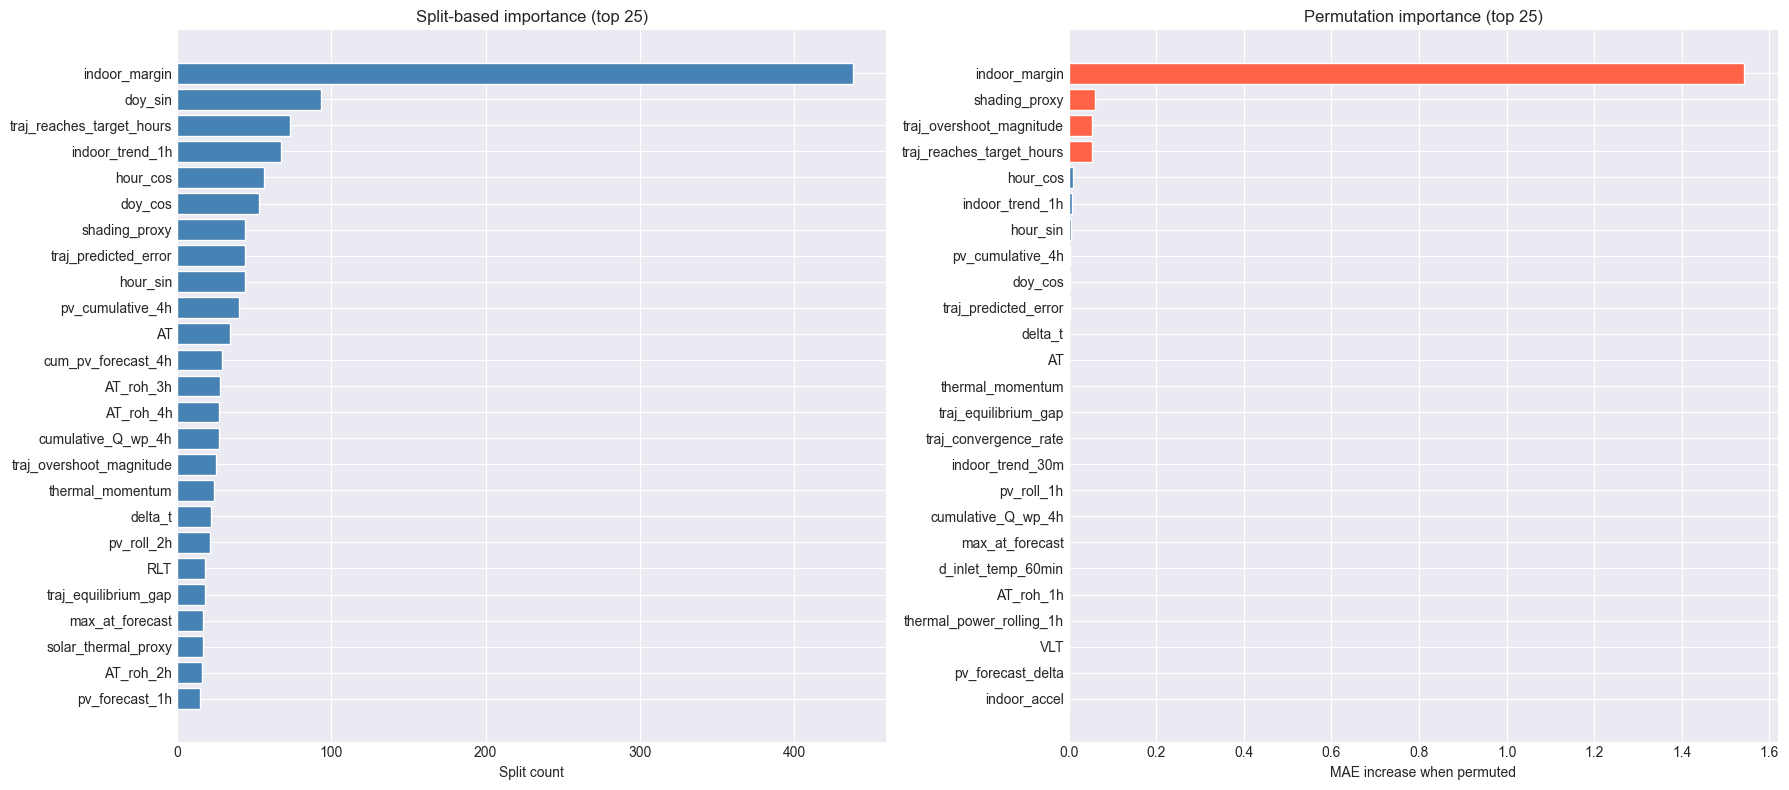

In [12]:
# ── Permutation importance ─────────────────────────────────────────────────
print("Computing permutation importance (10 repeats)…")
perm_result = permutation_importance(
    model, X_val, y_adj_val,
    n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)

pi = dict(zip(FEATURE_COLS, perm_result.importances_mean))
pi_sorted = sorted(pi.items(), key=lambda x: x[1], reverse=True)

print("\n=== PERMUTATION IMPORTANCE ===")
for name, imp in pi_sorted:
    marker = "★" if imp > 0.01 else "●" if imp > 0.001 else "○" if imp > 0 else "✂"
    print(f"  {marker} {name:35s} {imp:>10.4f}")

# Dominance check
top_pi = pi_sorted[0][1]
second_pi = pi_sorted[1][1] if len(pi_sorted) > 1 else 0
ratio = top_pi / max(second_pi, 1e-9)
print(f"\nTop: {pi_sorted[0][0]} ({top_pi:.4f})  2nd: {pi_sorted[1][0]} ({second_pi:.4f})  Ratio: {ratio:.1f}x")

# Importance plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top25_fi = fi_sorted[:25]
axes[0].barh([x[0] for x in top25_fi][::-1], [x[1] for x in top25_fi][::-1],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Split count"); axes[0].set_title("Split-based importance (top 25)")

top25_pi = pi_sorted[:25]
colors = ["tomato" if v > 0.01 else "steelblue" if v > 0 else "lightgrey" for _, v in top25_pi]
axes[1].barh([x[0] for x in top25_pi][::-1], [x[1] for x in top25_pi][::-1],
             color=colors[::-1], edgecolor="white")
axes[1].set_xlabel("MAE increase when permuted")
axes[1].set_title("Permutation importance (top 25)")
plt.tight_layout(); plt.show()

## 7. Incremental PI-Based Pruning

In [13]:
MAX_MAE_REGRESSION_PCT = 0.5
INCREMENTAL_PI_THRESHOLD = 0.001

inc_feats = FEATURE_COLS.copy()
inc_mae = adj_mae
inc_model = model
inc_log = []

print("=== INCREMENTAL PRUNING ===")
print(f"Starting: {len(inc_feats)} features, MAE={inc_mae:.4f}")

max_steps = len(inc_feats) - 5

for step in range(1, max_steps + 1):
    feat_idx = [FEATURE_COLS.index(f) for f in inc_feats]
    X_v = X_val[:, feat_idx]

    perm = permutation_importance(
        inc_model, X_v, y_adj_val,
        n_repeats=10, random_state=42,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    pi_dict = dict(zip(inc_feats, perm.importances_mean))

    candidates = [(f, pi_dict[f]) for f in inc_feats if pi_dict[f] < INCREMENTAL_PI_THRESHOLD]
    if not candidates:
        print(f"  Step {step}: No features with PI < {INCREMENTAL_PI_THRESHOLD} — converged ✓")
        break

    candidates.sort(key=lambda x: x[1])
    worst_feat, worst_pi = candidates[0]

    remaining = [f for f in inc_feats if f != worst_feat]
    r_idx = [FEATURE_COLS.index(f) for f in remaining]
    X_tr_r = X_train[:, r_idx]
    X_val_r = X_val[:, r_idx]

    m_inc = lgb.LGBMRegressor(**LGB_PARAMS)
    m_inc.fit(
        X_tr_r, y_adj_train,
        eval_set=[(X_val_r, y_adj_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_inc = m_inc.predict(X_val_r)
    mae_inc = mean_absolute_error(y_adj_val, yp_inc)
    r2_inc = r2_score(y_adj_val, yp_inc)
    mae_chg = (mae_inc - inc_mae) / inc_mae * 100

    inc_log.append({
        "step": step, "dropped": worst_feat, "pi": worst_pi,
        "n_remaining": len(remaining), "mae": mae_inc, "r2": r2_inc,
        "mae_change_pct": mae_chg,
    })

    if mae_chg <= MAX_MAE_REGRESSION_PCT:
        print(f"  Step {step}: DROP {worst_feat:30s} PI={worst_pi:+.5f}  "
              f"MAE {inc_mae:.4f}→{mae_inc:.4f} ({mae_chg:+.2f}%)  R²={r2_inc:.4f}  ✅")
        inc_feats = remaining
        inc_mae = mae_inc
        inc_model = m_inc
    else:
        print(f"  Step {step}: KEEP {worst_feat:30s} PI={worst_pi:+.5f}  "
              f"MAE {inc_mae:.4f}→{mae_inc:.4f} ({mae_chg:+.2f}%)  ⛔ STOP")
        break

PRUNED_FEATS = inc_feats
current_mae = inc_mae
current_model = inc_model

dropped = sorted(set(FEATURE_COLS) - set(PRUNED_FEATS))
print(f"\n{'='*70}")
print(f"PRUNING COMPLETE: {len(FEATURE_COLS)} → {len(PRUNED_FEATS)} features")
print(f"Dropped ({len(dropped)}): {dropped}")
print(f"Final adjusted-label MAE = {inc_mae:.4f}")

=== INCREMENTAL PRUNING ===
Starting: 63 features, MAE=0.2510


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Step 1: KEEP cum_pv_forecast_4h             PI=-0.00222  MAE 0.2510→0.2567 (+2.27%)  ⛔ STOP

PRUNING COMPLETE: 63 → 63 features
Dropped (0): []
Final adjusted-label MAE = 0.2510


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [14]:
# ── Pruned model: reconstruction metrics ───────────────────────────────────
pruned_idx = [FEATURE_COLS.index(f) for f in PRUNED_FEATS]
X_val_pruned = X_val[:, pruned_idx]

y_adj_pred_pruned = current_model.predict(X_val_pruned)
y_orig_pred_pruned = y_adj_pred_pruned - margin_val / S_H

pruned_adj_mae = mean_absolute_error(y_adj_val, y_adj_pred_pruned)
pruned_adj_r2 = r2_score(y_adj_val, y_adj_pred_pruned)
pruned_recon_mae = mean_absolute_error(y_orig_val, y_orig_pred_pruned)
pruned_recon_r2 = r2_score(y_orig_val, y_orig_pred_pruned)

print(f"Pruned model ({len(PRUNED_FEATS)} features):")
print(f"  Adjusted label:  MAE={pruned_adj_mae:.4f}  R²={pruned_adj_r2:.4f}")
print(f"  Reconstructed:   MAE={pruned_recon_mae:.4f}  R²={pruned_recon_r2:.4f}  (original label)")

Pruned model (63 features):
  Adjusted label:  MAE=0.2510  R²=0.9621
  Reconstructed:   MAE=0.2510  R²=0.8530  (original label)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Optuna Re-Tuning

In [15]:
RUN_OPTUNA = True
N_OPTUNA_TRIALS = 50

if RUN_OPTUNA and USE_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    X_train_pruned = X_train[:, pruned_idx]

    def objective(trial):
        params = {
            "objective": "regression_l1",
            "metric": "mae",
            "n_estimators": 300,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 42, "n_jobs": -1, "verbose": -1,
        }
        tscv_opt = TimeSeriesSplit(n_splits=3)
        fold_maes = []
        for tr_i, val_i in tscv_opt.split(X_train_pruned):
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_train_pruned[tr_i], y_adj_train[tr_i],
                eval_set=[(X_train_pruned[val_i], y_adj_train[val_i])],
                eval_metric="mae",
                callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
            )
            fold_maes.append(mean_absolute_error(y_adj_train[val_i], m.predict(X_train_pruned[val_i])))
        return np.mean(fold_maes)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    print(f"\n=== OPTUNA BEST (n_trials={N_OPTUNA_TRIALS}, CV MAE={study.best_value:.4f}) ===")
    for k, v in study.best_params.items():
        print(f"  {k:25s} {v}")

    best_params = {**LGB_PARAMS, **study.best_params}
    model_optuna = lgb.LGBMRegressor(**best_params)
    model_optuna.fit(
        X_train_pruned, y_adj_train,
        eval_set=[(X_val_pruned, y_adj_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    y_adj_optuna = model_optuna.predict(X_val_pruned)
    y_orig_optuna = y_adj_optuna - margin_val / S_H

    optuna_adj_mae = mean_absolute_error(y_adj_val, y_adj_optuna)
    optuna_recon_mae = mean_absolute_error(y_orig_val, y_orig_optuna)
    optuna_recon_r2 = r2_score(y_orig_val, y_orig_optuna)

    print(f"\nOptuna: adj MAE={optuna_adj_mae:.4f}  R²={r2_score(y_adj_val, y_adj_optuna):.4f}")
    print(f"        recon MAE={optuna_recon_mae:.4f}  R²={optuna_recon_r2:.4f}")

    if optuna_recon_mae < pruned_recon_mae:
        print(f"\n✅ Optuna improves: {optuna_recon_mae:.4f} < {pruned_recon_mae:.4f}")
        model_final = model_optuna
        y_adj_final = y_adj_optuna
        y_orig_final = y_orig_optuna
        final_adj_mae = optuna_adj_mae
        final_adj_r2 = r2_score(y_adj_val, y_adj_optuna)
        final_recon_mae = optuna_recon_mae
        final_recon_r2 = optuna_recon_r2
    else:
        print(f"\n⚠️  Optuna worse: {optuna_recon_mae:.4f} ≥ {pruned_recon_mae:.4f} — keeping default")
        model_final = current_model
        y_adj_final = y_adj_pred_pruned
        y_orig_final = y_orig_pred_pruned
        final_adj_mae = pruned_adj_mae
        final_adj_r2 = pruned_adj_r2
        final_recon_mae = pruned_recon_mae
        final_recon_r2 = pruned_recon_r2
        best_params = LGB_PARAMS
else:
    model_final = current_model
    y_adj_final = y_adj_pred_pruned
    y_orig_final = y_orig_pred_pruned
    final_adj_mae = pruned_adj_mae
    final_adj_r2 = pruned_adj_r2
    final_recon_mae = pruned_recon_mae
    final_recon_r2 = pruned_recon_r2
    best_params = LGB_PARAMS

print(f"\n{'='*60}")
print(f"FINAL MODEL: MAE={final_recon_mae:.4f}  R²={final_recon_r2:.4f}  "
      f"({len(PRUNED_FEATS)} features)")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid 


=== OPTUNA BEST (n_trials=50, CV MAE=0.2347) ===
  learning_rate             0.11470173104394334
  max_depth                 7
  num_leaves                15
  min_child_samples         11
  reg_alpha                 0.057803318421884846
  reg_lambda                0.4666405141301816

Optuna: adj MAE=0.2577  R²=0.9599
        recon MAE=0.2577  R²=0.8445

⚠️  Optuna worse: 0.2577 ≥ 0.2510 — keeping default

FINAL MODEL: MAE=0.2510  R²=0.8530  (63 features)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 9. Time-Series Cross-Validation

In [16]:
N_CV_FOLDS = 5

X_pruned_all = model_df[PRUNED_FEATS].values
y_adj_all = model_df["adjusted_label"].values
y_orig_all = model_df["label_reg"].values
margin_all = model_df["indoor_margin"].values

tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)
cv_adj_maes, cv_adj_r2s = [], []
cv_recon_maes, cv_recon_r2s = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_pruned_all)):
    m_cv = lgb.LGBMRegressor(**best_params)
    m_cv.fit(
        X_pruned_all[tr_idx], y_adj_all[tr_idx],
        eval_set=[(X_pruned_all[val_idx], y_adj_all[val_idx])],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_cv = m_cv.predict(X_pruned_all[val_idx])

    fold_adj_mae = mean_absolute_error(y_adj_all[val_idx], yp_cv)
    fold_adj_r2 = r2_score(y_adj_all[val_idx], yp_cv)
    cv_adj_maes.append(fold_adj_mae)
    cv_adj_r2s.append(fold_adj_r2)

    yp_recon = yp_cv - margin_all[val_idx] / S_H
    fold_recon_mae = mean_absolute_error(y_orig_all[val_idx], yp_recon)
    fold_recon_r2 = r2_score(y_orig_all[val_idx], yp_recon)
    cv_recon_maes.append(fold_recon_mae)
    cv_recon_r2s.append(fold_recon_r2)

    print(f"  Fold {fold+1}: adj MAE={fold_adj_mae:.4f} R²={fold_adj_r2:.4f}  "
          f"| recon MAE={fold_recon_mae:.4f} R²={fold_recon_r2:.4f}")

print(f"\n=== {N_CV_FOLDS}-FOLD TIME-SERIES CV ===")
print(f"  Adjusted: MAE={np.mean(cv_adj_maes):.4f}±{np.std(cv_adj_maes):.4f}  "
      f"R²={np.mean(cv_adj_r2s):.4f}±{np.std(cv_adj_r2s):.4f}")
print(f"  Recon:    MAE={np.mean(cv_recon_maes):.4f}±{np.std(cv_recon_maes):.4f}  "
      f"R²={np.mean(cv_recon_r2s):.4f}±{np.std(cv_recon_r2s):.4f}")
print(f"\n  Heating 08_ CV: adj MAE=0.1328±0.0150  R²=0.9653±0.0110")
print(f"  Heating 08_ CV: recon MAE=0.1328±0.0150  R²=0.8642±0.0410")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 1: adj MAE=0.2803 R²=0.9721  | recon MAE=0.2803 R²=0.8865
  Fold 2: adj MAE=0.2238 R²=0.9823  | recon MAE=0.2238 R²=0.9276


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 3: adj MAE=0.3698 R²=0.9612  | recon MAE=0.3698 R²=0.8394
  Fold 4: adj MAE=0.2841 R²=0.9404  | recon MAE=0.2841 R²=0.7749
  Fold 5: adj MAE=0.2280 R²=0.9710  | recon MAE=0.2280 R²=0.8858

=== 5-FOLD TIME-SERIES CV ===
  Adjusted: MAE=0.2772±0.0527  R²=0.9654±0.0142
  Recon:    MAE=0.2772±0.0527  R²=0.8628±0.0521

  Heating 08_ CV: adj MAE=0.1328±0.0150  R²=0.9653±0.0110
  Heating 08_ CV: recon MAE=0.1328±0.0150  R²=0.8642±0.0410


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 10. Diagnostics

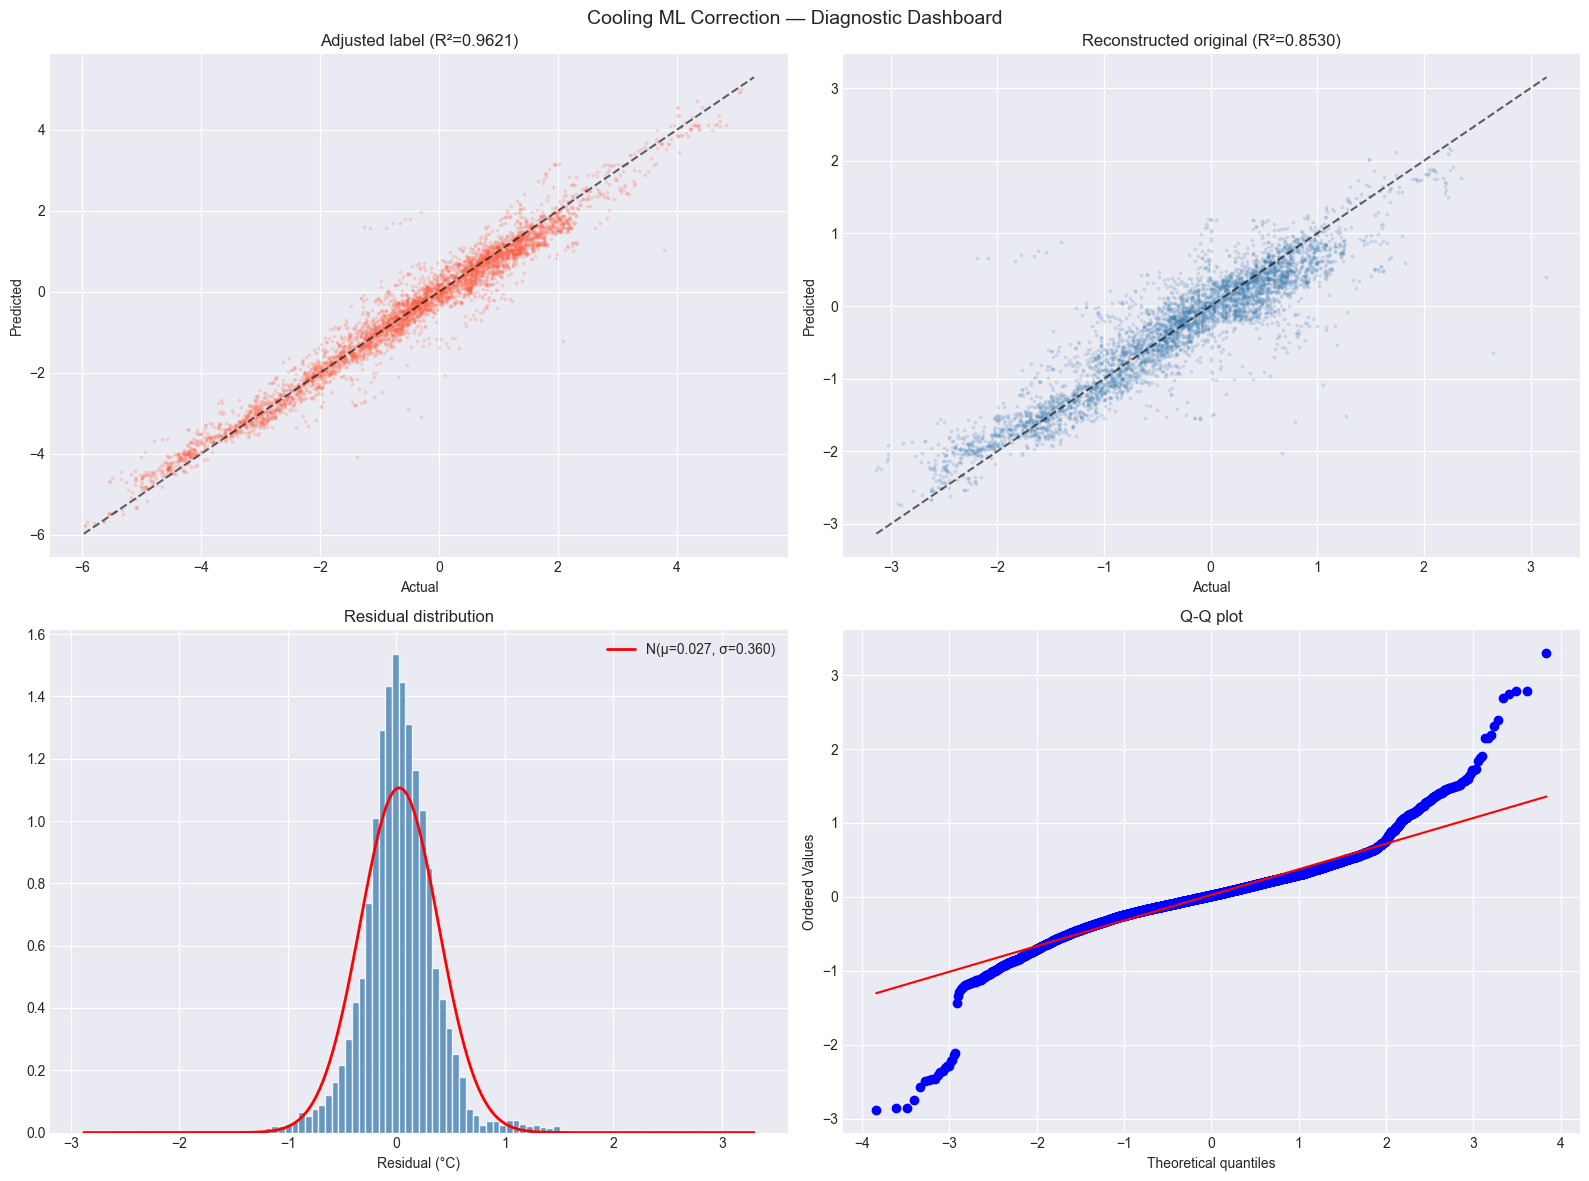

In [17]:
# ── Predicted vs Actual + Residual Analysis ────────────────────────────────
residuals_recon = y_orig_val - y_orig_final

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sample_d = np.random.RandomState(42).choice(len(y_orig_val), min(5000, len(y_orig_val)), replace=False)

# 1. Pred vs actual (adjusted)
axes[0,0].scatter(y_adj_val[sample_d], y_adj_final[sample_d], alpha=0.15, s=3, color="tomato")
lims = [min(y_adj_val.min(), y_adj_final.min()), max(y_adj_val.max(), y_adj_final.max())]
axes[0,0].plot(lims, lims, "k--", alpha=0.6)
axes[0,0].set_xlabel("Actual"); axes[0,0].set_ylabel("Predicted")
axes[0,0].set_title(f"Adjusted label (R²={final_adj_r2:.4f})")

# 2. Pred vs actual (reconstructed)
axes[0,1].scatter(y_orig_val[sample_d], y_orig_final[sample_d], alpha=0.15, s=3, color="steelblue")
lims2 = [min(y_orig_val.min(), y_orig_final.min()), max(y_orig_val.max(), y_orig_final.max())]
axes[0,1].plot(lims2, lims2, "k--", alpha=0.6)
axes[0,1].set_xlabel("Actual"); axes[0,1].set_ylabel("Predicted")
axes[0,1].set_title(f"Reconstructed original (R²={final_recon_r2:.4f})")

# 3. Residual histogram
axes[1,0].hist(residuals_recon, bins=100, color="steelblue", edgecolor="white", alpha=0.8, density=True)
x_n = np.linspace(residuals_recon.min(), residuals_recon.max(), 200)
axes[1,0].plot(x_n, stats.norm.pdf(x_n, residuals_recon.mean(), residuals_recon.std()),
               "r-", lw=2, label=f"N(μ={residuals_recon.mean():.3f}, σ={residuals_recon.std():.3f})")
axes[1,0].set_xlabel("Residual (°C)"); axes[1,0].legend()
axes[1,0].set_title("Residual distribution")

# 4. Q-Q plot
stats.probplot(residuals_recon, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q plot")

plt.suptitle("Cooling ML Correction — Diagnostic Dashboard", fontsize=14)
plt.tight_layout(); plt.show()

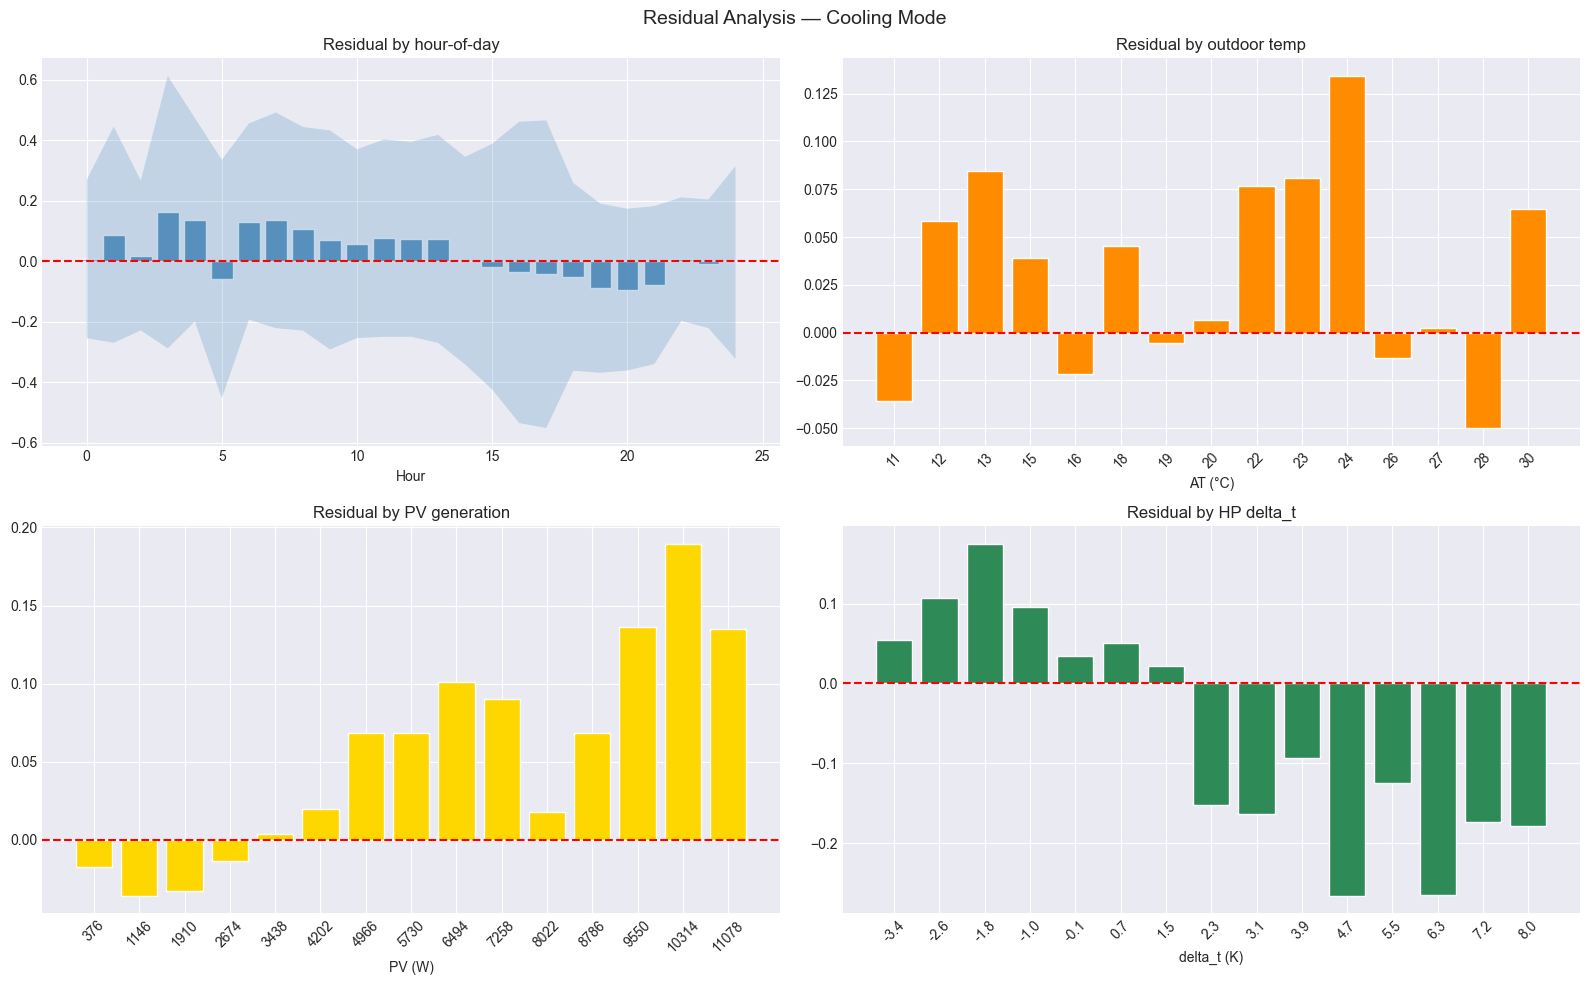

In [18]:
# ── Residual by context features ───────────────────────────────────────────
val_df = model_df.iloc[split_idx:].copy()
val_df = val_df.iloc[:len(residuals_recon)].copy()
val_df["residual"] = residuals_recon

approx_hour = np.arctan2(val_df["hour_sin"], val_df["hour_cos"]) * 24 / (2 * np.pi) % 24
val_df["approx_hour"] = approx_hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. By hour
hr = val_df.groupby(val_df["approx_hour"].round())["residual"].agg(["mean", "std"])
axes[0,0].bar(hr.index, hr["mean"], color="steelblue", edgecolor="white", alpha=0.8)
axes[0,0].fill_between(hr.index, hr["mean"]-hr["std"], hr["mean"]+hr["std"], alpha=0.2)
axes[0,0].axhline(0, color="red", linestyle="--")
axes[0,0].set_xlabel("Hour"); axes[0,0].set_title("Residual by hour-of-day")

# 2. By AT
at_bins = pd.cut(val_df["AT"], bins=15)
at_res = val_df.groupby(at_bins, observed=True)["residual"].mean()
axes[0,1].bar(range(len(at_res)), at_res.values, color="darkorange", edgecolor="white")
axes[0,1].set_xticks(range(len(at_res)))
axes[0,1].set_xticklabels([f"{x.mid:.0f}" for x in at_res.index], rotation=45)
axes[0,1].axhline(0, color="red", linestyle="--")
axes[0,1].set_xlabel("AT (°C)"); axes[0,1].set_title("Residual by outdoor temp")

# 3. By PV
pv_clip = val_df["PV_Generate"].clip(upper=val_df["PV_Generate"].quantile(0.99))
pv_bins = pd.cut(pv_clip, bins=15)
pv_res = val_df.groupby(pv_bins, observed=True)["residual"].mean()
axes[1,0].bar(range(len(pv_res)), pv_res.values, color="gold", edgecolor="white")
axes[1,0].set_xticks(range(len(pv_res)))
axes[1,0].set_xticklabels([f"{x.mid:.0f}" for x in pv_res.index], rotation=45)
axes[1,0].axhline(0, color="red", linestyle="--")
axes[1,0].set_xlabel("PV (W)"); axes[1,0].set_title("Residual by PV generation")

# 4. By delta_t
dt_bins = pd.cut(val_df["delta_t"], bins=15)
dt_res = val_df.groupby(dt_bins, observed=True)["residual"].mean()
axes[1,1].bar(range(len(dt_res)), dt_res.values, color="seagreen", edgecolor="white")
axes[1,1].set_xticks(range(len(dt_res)))
axes[1,1].set_xticklabels([f"{x.mid:.1f}" for x in dt_res.index], rotation=45)
axes[1,1].axhline(0, color="red", linestyle="--")
axes[1,1].set_xlabel("delta_t (K)"); axes[1,1].set_title("Residual by HP delta_t")

plt.suptitle("Residual Analysis — Cooling Mode", fontsize=14)
plt.tight_layout(); plt.show()

## 11. Comparison: Cooling vs Heating

In [19]:
print("="*72)
print("  COOLING vs HEATING ML CORRECTION — COMPARISON")
print("="*72)
print()
print(f"  {'Metric':<30s} {'Cooling':>15s} {'Heating 08_':>15s}")
print(f"  {'─'*30} {'─'*15} {'─'*15}")
print(f"  {'Adj. label MAE':<30s} {final_adj_mae:>14.4f}° {'0.1277':>15s}")
print(f"  {'Adj. label R²':<30s} {final_adj_r2:>15.4f} {'0.9755':>15s}")
print(f"  {'Recon. orig. MAE':<30s} {final_recon_mae:>14.4f}° {'0.1277':>15s}")
print(f"  {'Recon. orig. R²':<30s} {final_recon_r2:>15.4f} {'0.9042':>15s}")
print(f"  {'Features (pruned)':<30s} {len(PRUNED_FEATS):>15d} {'53':>15s}")
print(f"  {'Training rows':<30s} {len(X_train):>15,} {'58,862':>15s}")
print(f"  {'S_H':<30s} {S_H:>15.4f} {'0.4920':>15s}")
print(f"  {'OE':<30s} {OE_COOLING:>15.2f} {'0.85':>15s}")
print(f"  {'Target temp':<30s} {COOLING_TARGET_C:>14.1f}° {'22.6':>15s}")
print()
print(f"  {'CV adj MAE':<30s} {np.mean(cv_adj_maes):>7.4f}±{np.std(cv_adj_maes):.4f}  {'0.1328±0.0150':>15s}")
print(f"  {'CV adj R²':<30s} {np.mean(cv_adj_r2s):>7.4f}±{np.std(cv_adj_r2s):.4f}  {'0.9653±0.0110':>15s}")
print(f"  {'CV recon MAE':<30s} {np.mean(cv_recon_maes):>7.4f}±{np.std(cv_recon_maes):.4f}  {'0.1328±0.0150':>15s}")
print(f"  {'CV recon R²':<30s} {np.mean(cv_recon_r2s):>7.4f}±{np.std(cv_recon_r2s):.4f}  {'0.8642±0.0410':>15s}")
print()
print("  Key differences:")
print(f"  • Cooling S_H={S_H:.4f} (OE_cooling=0.20) vs Heating S_H=0.492 (OE=0.85)")
print(f"  • Lower S_H → larger label magnitudes → harder regression target")
print(f"  • Cooling data: {len(model_df):,} rows (warm season only)")
print(f"  • Heating data: 78,483 rows (cold season, more data)")
print("="*72)

  COOLING vs HEATING ML CORRECTION — COMPARISON

  Metric                                 Cooling     Heating 08_
  ────────────────────────────── ─────────────── ───────────────
  Adj. label MAE                         0.2510°          0.1277
  Adj. label R²                           0.9621          0.9755
  Recon. orig. MAE                       0.2510°          0.1277
  Recon. orig. R²                         0.8530          0.9042
  Features (pruned)                           63              53
  Training rows                           33,482          58,862
  S_H                                     0.3508          0.4920
  OE                                        0.20            0.85
  Target temp                              23.0°            22.6

  CV adj MAE                      0.2772±0.0527    0.1328±0.0150
  CV adj R²                       0.9654±0.0142    0.9653±0.0110
  CV recon MAE                    0.2772±0.0527    0.1328±0.0150
  CV recon R²                     0.8628

## 12. Summary & Next Steps

In [20]:
print("="*72)
print("  NOTEBOOK 09 — COOLING ML CORRECTION SUMMARY")
print("="*72)
print()
print("  ── Architecture ──")
print(f"  Label:    adjusted = -(T_future - T_current) / S_H_cooling")
print(f"  Inference: full_correction = model.predict(X) - indoor_margin / S_H_cooling")
print(f"  S_H_cooling = {S_H:.4f}  (OE={OE_COOLING}, HLC={HLC}, τ={TAU_ROOM}h)")
print()
print("  ── Performance ──")
print(f"  Final adj. label:   MAE={final_adj_mae:.4f}  R²={final_adj_r2:.4f}")
print(f"  Final reconstructed: MAE={final_recon_mae:.4f}  R²={final_recon_r2:.4f}")
print(f"  Features:           {len(PRUNED_FEATS)} (pruned from {len(FEATURE_COLS)})")
print()
print("  ── Pruned Feature List ──")
for i, f in enumerate(PRUNED_FEATS):
    print(f"    {i+1:2d}. {f}")
print()
if set(FEATURE_COLS) - set(PRUNED_FEATS):
    print(f"  Dropped: {sorted(set(FEATURE_COLS) - set(PRUNED_FEATS))}")
    print()
print("  ── Next Steps for Production ──")
print("  1. Add cooling regression label to cooling_ml_calibration.py")
print("  2. Create cooling_correction_ml_model.py (analog to heating)")
print("  3. Add cooling ML correction blend in model_wrapper.py")
print("  4. Compute S_H_cooling from calibrated OE/HLC/τ at runtime")
print("  5. Add adjusted-label reconstruction step at inference")
print("="*72)

  NOTEBOOK 09 — COOLING ML CORRECTION SUMMARY

  ── Architecture ──
  Label:    adjusted = -(T_future - T_current) / S_H_cooling
  Inference: full_correction = model.predict(X) - indoor_margin / S_H_cooling
  S_H_cooling = 0.3508  (OE=0.2, HLC=0.1206, τ=4.84h)

  ── Performance ──
  Final adj. label:   MAE=0.2510  R²=0.9621
  Final reconstructed: MAE=0.2510  R²=0.8530
  Features:           63 (pruned from 63)

  ── Pruned Feature List ──
     1. indoor_margin
     2. indoor_trend_30m
     3. indoor_trend_1h
     4. indoor_temp_gradient
     5. indoor_margin_rate
     6. is_overshoot
     7. indoor_accel
     8. indoor_momentum
     9. AT
    10. at_delta_indoor
    11. AT_roh_1h
    12. AT_roh_2h
    13. AT_roh_3h
    14. AT_roh_4h
    15. AT_forecast_trend
    16. cum_at_excess_4h
    17. max_at_forecast
    18. PV_Generate
    19. pv_roll_1h
    20. pv_roll_2h
    21. pv_forecast_1h
    22. pv_forecast_2h
    23. pv_forecast_3h
    24. pv_forecast_4h
    25. pv_forecast_delta
    26.